In [ ]:
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/cta0001.wav
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/cta0001.seg_G1

In [174]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython.display import Audio

signal, fs = librosa.load(r"cta0001.wav")

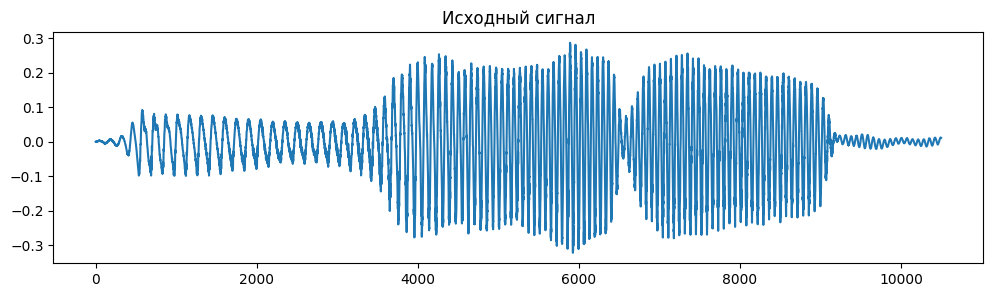

In [175]:
signal = signal[:10500]

plt.figure(figsize=(12, 3))
plt.plot(signal)
plt.title("Исходный сигнал")
plt.show()

In [176]:
display(Audio(signal, rate=fs))

10500 83


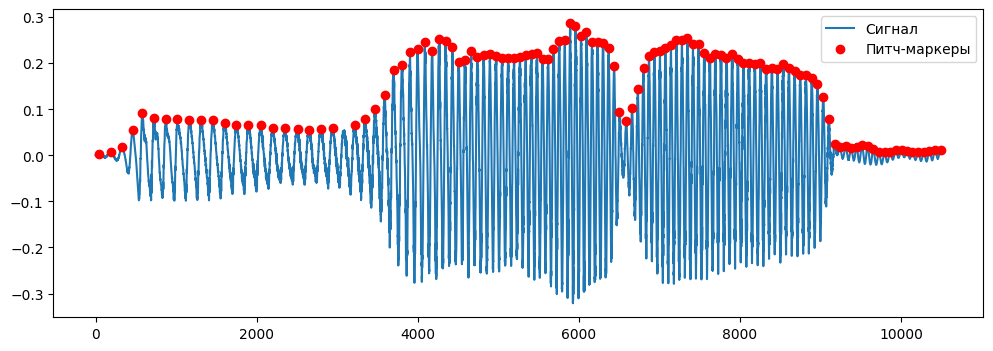

In [180]:
def detect_pitch_marks_pyin(signal, fs, fmin=40, fmax=500, hop_length=128):
    f0, voiced_flag, voiced_probs = librosa.pyin(
        signal, fmin=fmin, fmax=fmax, sr=fs,
        hop_length=hop_length, fill_na=0
    )

    print(len(signal), len(f0))

    times = librosa.frames_to_time(np.arange(len(f0)), sr=fs, hop_length=hop_length)
    marks = []

    # Текущая позиция в отсчетах
    curr_samp = 0

    while curr_samp < len(signal):
        # Находим, какой частоте F0 соответствует текущий отсчет
        # Интерполируем F0 из сетки pyin в конкретную точку curr_samp
        idx = min(int(curr_samp / hop_length), len(f0) - 1)
        current_f0 = f0[idx]

        if current_f0 > 0:
            # длина перидов в отсчетах
            period_samples = int(fs / current_f0)

            # Ищем уточненный пик в окрестности текущей точки
            search_range = period_samples // 2
            start = max(0, curr_samp - search_range)
            end = min(len(signal), curr_samp + search_range)

            if start < end:
                peak_idx = np.argmax(signal[start:end]) + start
                marks.append(peak_idx)
                # идем на один целый период вперед от найденного пика
                curr_samp = peak_idx + period_samples
            else:
                curr_samp += hop_length
        else:
            # Если участок глухой (F0=0), просто двигаемся вперед на следующий фрейм
            curr_samp += hop_length

    return np.array(marks)


marks = detect_pitch_marks_pyin(signal, fs)

# Визуализация
plt.figure(figsize=(12, 4))
plt.plot(signal, label='Сигнал')
plt.plot(marks, signal[marks], 'ro', label='Питч-маркеры')
plt.legend()
plt.show()

In [181]:
def change_duration_td_psola(signal, marks, duration_factor):
    if len(marks) < 2:
        return signal

    # Массив локальных периодов (расстояние до следующей метки)
    periods = np.diff(marks)
    periods = np.append(periods, periods[-1]) # Дублируем последний для длины

    # Новая временная сетка для синтеза
    new_duration = marks[-1] * duration_factor
    output = np.zeros(int(new_duration) + int(np.max(periods) * 2))

    curr_pos_out = marks[0] # Начинаем с первой метки

    while curr_pos_out < new_duration:
        # Находим, какому моменту в оригинале соответствует текущая позиция
        source_pos = curr_pos_out / duration_factor

        # Ищем индекс ближайшей оригинальной метки
        idx = np.argmin(np.abs(marks - source_pos))
        source_mark = marks[idx]
        local_T = int(periods[idx]) # Локальный период в этой точке

        # Окно размером в 2 локальных периода
        win_size = local_T * 2
        window = np.hanning(win_size)
        half_win = win_size // 2

        # Вырезаем сегмент из оригинала
        start = int(source_mark - half_win)
        end = start + win_size

        if start >= 0 and end < len(signal):
            segment = signal[start:end] * window

            # Накладываем в выходной буфер
            out_start = int(curr_pos_out - half_win)
            out_end = out_start + win_size
            if out_end < len(output):
                output[out_start:out_end] += segment

        # прибавляем локальный период
        curr_pos_out += local_T

    output = output / (np.max(np.abs(output)) + 1e-6)
    return output

# растяжение в 2 раза
slow_signal = change_duration_td_psola(signal, marks, duration_factor=2)
display(Audio(slow_signal, rate=fs))

In [182]:
def change_pitch_td_psola(signal, marks, pitch_factor):
    if len(marks) < 2:
        return signal

    # Считаем локальные периоды
    periods = np.diff(marks)
    periods = np.append(periods, periods[-1]) # Дублируем для последнего участка

    # Создаем выходную сетку с запасом
    max_T = np.max(periods) / pitch_factor
    output = np.zeros(len(signal) + int(max_T * 4))

    curr_pos_out = float(marks[0]) # Начинаем с первой метки
    target_duration = float(marks[-1])

    while curr_pos_out < target_duration:
        # Находим индекс ближайшей оригинальной метки к текущему времени выхода
        idx = np.argmin(np.abs(marks - curr_pos_out))
        source_mark = marks[idx]

        # Новый локальный период
        new_T = periods[idx] / pitch_factor

        # Размер окна должен быть 2 новых периода для плавности
        win_size = int(new_T * 2)
        if win_size < 2: win_size = 2 # Защита от деления на 0

        window = np.hanning(win_size)
        half_win = win_size // 2

        # Определяем границы в оригинальном сигнале вокруг найденной метки
        start = int(source_mark - half_win)
        end = start + win_size

        # если сегмент выходит за границы сигнала, пропускаем итерацию
        if start >= 0 and end <= len(signal):
            segment = signal[start:end] * window

            # Накладываем в выходной буфер
            out_start = int(curr_pos_out - half_win)
            out_end = out_start + win_size

            if out_start >= 0 and out_end < len(output):
                # Проверка совпадения размеров
                if len(segment) == (out_end - out_start):
                    output[out_start:out_end] += segment

        # двигаемся по выходному сигналу с новым периодом
        curr_pos_out += new_T

    # Обрезаем лишнее и нормализуем
    output = output[:len(signal)]
    output /= (np.max(np.abs(output)) + 1e-6)
    return output


higher_signal = change_pitch_td_psola(signal, marks, pitch_factor=1.5)
display(Audio(higher_signal, rate=fs))

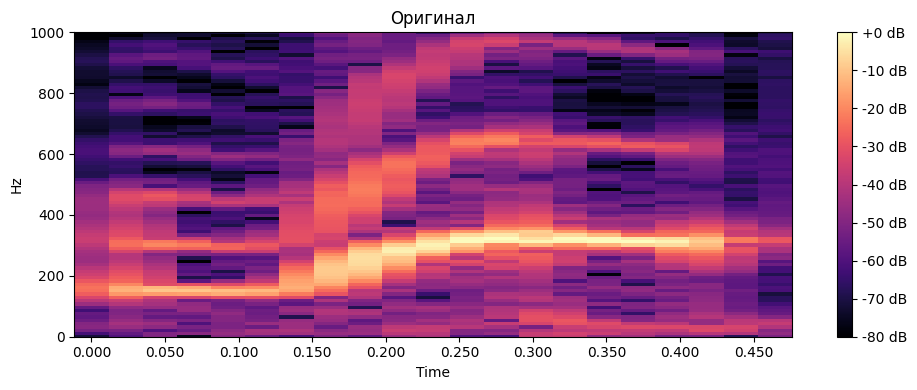

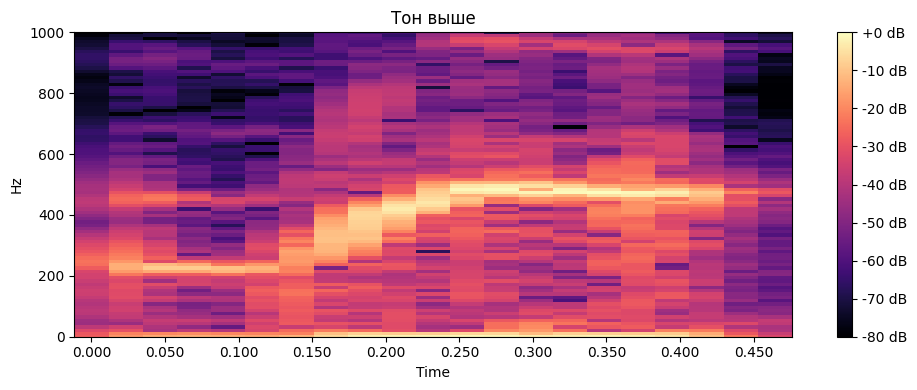

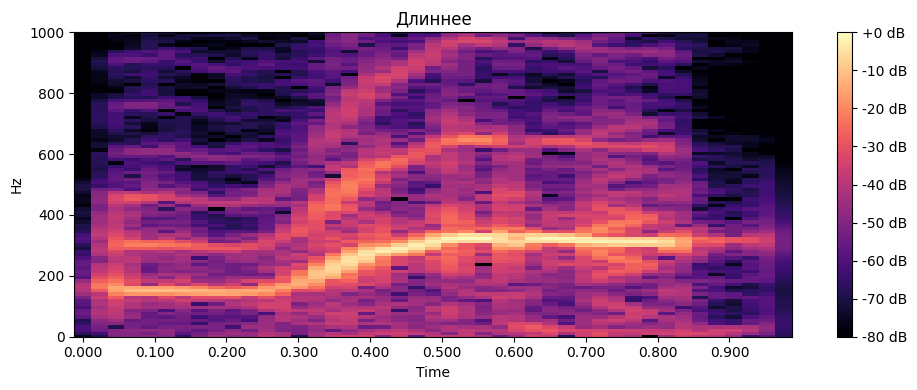

In [183]:
def plot_spectrogram(sig, fs, title):
    plt.figure(figsize=(10, 4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    librosa.display.specshow(D, sr=fs, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.ylim(0,1000)
    plt.show()

plot_spectrogram(signal, fs, "Оригинал")
plot_spectrogram(higher_signal, fs, "Тон выше")
plot_spectrogram(slow_signal, fs, "Длиннее")

Задание. Реализуйте алгоритм TD-PSOLA для изменения ЧОТ, но теперь замените метки периодов, найденные с помощью librosa на границы периодов ОТ, полученные из разметки seg_G1.